In [ ]:
!pip install shap -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nOutcome distribution:")
print(df["Outcome"].value_counts())

Dataset shape: (768, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
df_clean = df.copy()

zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_columns:
    df_clean[col] = df_clean[col].replace(0, np.nan)

for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after preprocessing:")
print(df_clean.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (768, 8)
Target: (768,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(random_state=42))
])

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test F1-Score:", f1)

Test Accuracy: 0.7077922077922078
Test F1-Score: 0.5454545454545454


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracy = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

cv_f1 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Cross-Validation Accuracy Scores:")
print(cv_accuracy)

print("\nMean CV Accuracy:", cv_accuracy.mean())

print("\nCross-Validation F1 Scores:")
print(cv_f1)

print("\nMean CV F1-Score:", cv_f1.mean())

Cross-Validation Accuracy Scores:
[0.78861789 0.7804878  0.82113821 0.7804878  0.76229508]

Mean CV Accuracy: 0.7866053578568573

Cross-Validation F1 Scores:
[0.63888889 0.64935065 0.69444444 0.64935065 0.62337662]

Mean CV F1-Score: 0.651082251082251


In [ ]:
brier = brier_score_loss(y_test, y_prob)

print("Brier Score:", brier)

Brier Score: 0.17541713693275893


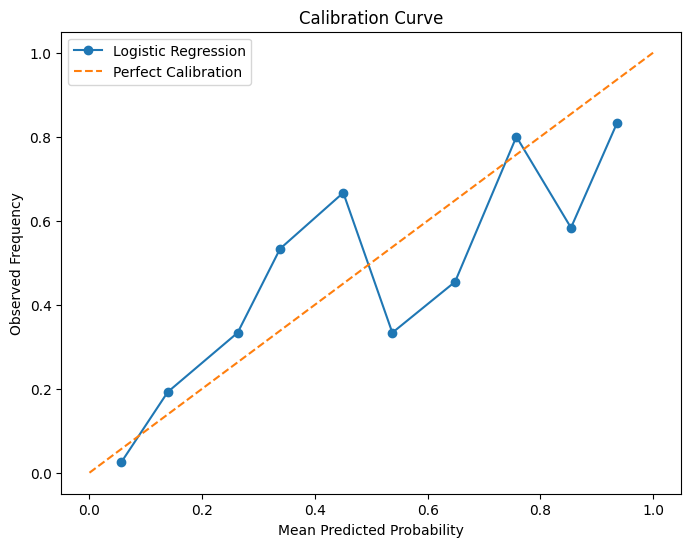

In [ ]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")

plt.legend()
plt.show()

In [ ]:
scaler = model.named_steps["scaler"]
logistic = model.named_steps["logistic"]

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

explainer = shap.LinearExplainer(
    logistic,
    X_train_scaled
)

shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


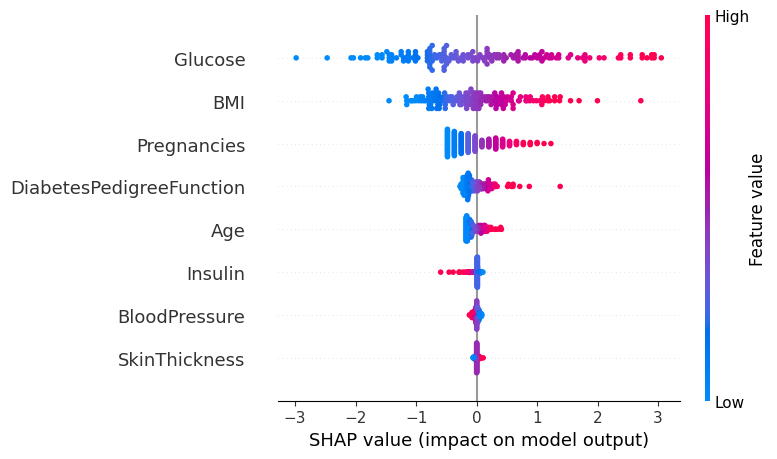

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

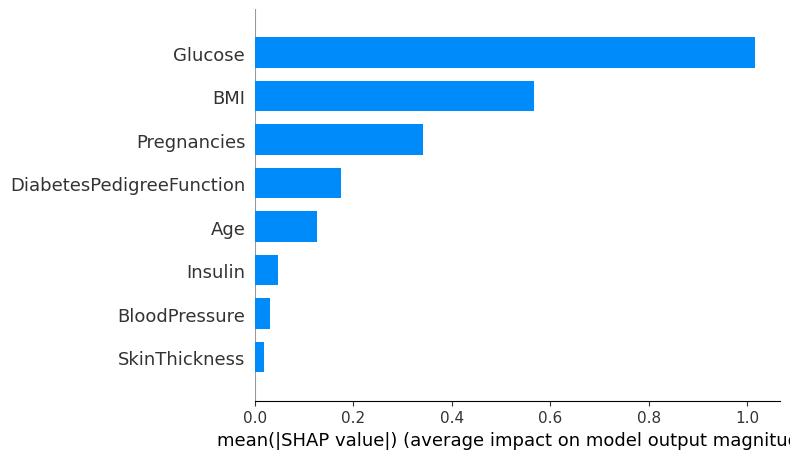

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar"
)

In [ ]:
sample_index = 0

print("Actual Outcome:", y_test.iloc[sample_index])
print("Predicted Outcome:", y_pred[sample_index])
print("Predicted Diabetes Probability:", y_prob[sample_index])

Actual Outcome: 0
Predicted Outcome: 1
Predicted Diabetes Probability: 0.6097107330034057


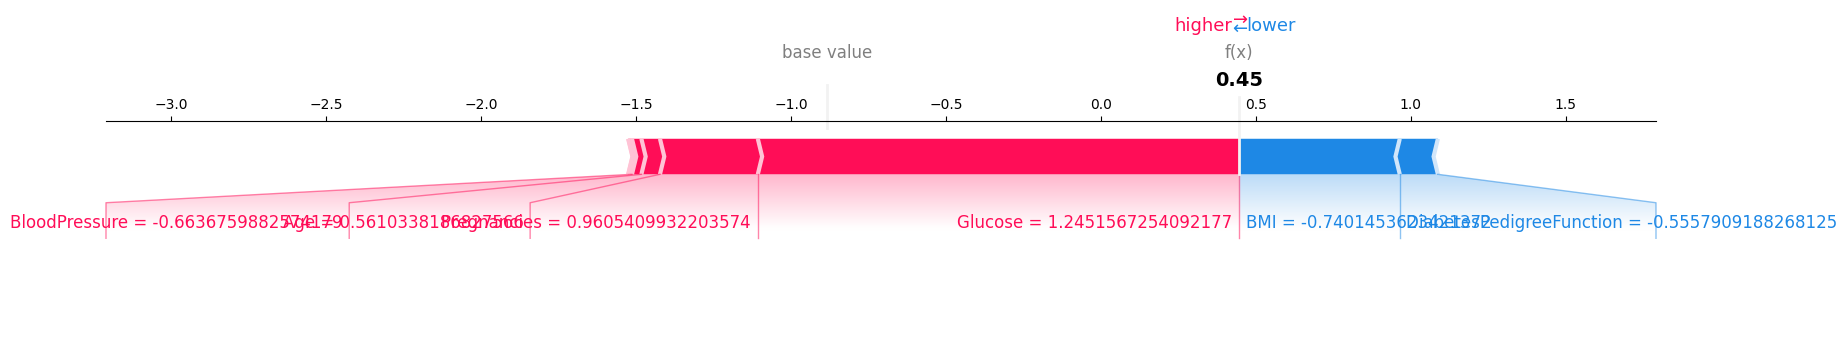

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test_scaled[sample_index],
    feature_names=X.columns,
    matplotlib=True
)

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean Absolute SHAP": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

print(feature_importance)

                    Feature  Mean Absolute SHAP
1                   Glucose            1.015550
5                       BMI            0.566419
0               Pregnancies            0.341287
6  DiabetesPedigreeFunction            0.173990
7                       Age            0.126332
4                   Insulin            0.046624
2             BloodPressure            0.031152
3             SkinThickness            0.017932
